In [3]:
import numpy as np
import matplotlib
import math

# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$. 

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

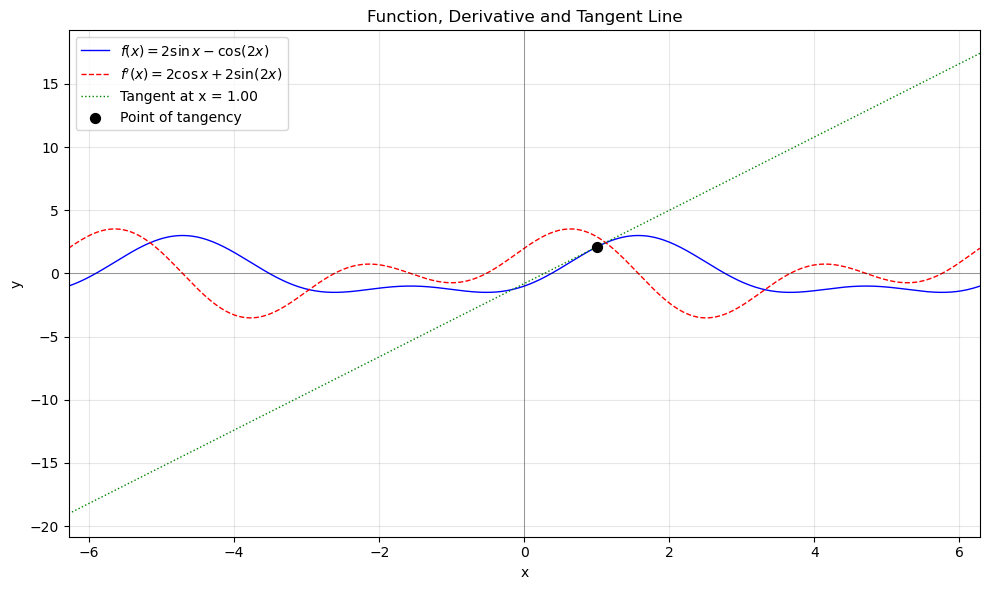

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):
    
    f = lambda x: 2 * np.sin(x) - np.cos(2 * x)
    
    f_prime = lambda x: 2 * np.cos(x) + 2 * np.sin(2 * x) 
    
    # Create values for the plot
    x = np.linspace(-2 * np.pi, 2 * np.pi, 500)
    y = f(x)
    y_prime = f_prime(x)
    
    y_tan = f(x0) + f_prime(x0) * (x - x0)
    
    # draw plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='$f(x) = 2\sin x - \cos(2x)$', color='blue', linewidth=1)
    plt.plot(x, y_prime, label="$f'(x) = 2\cos x + 2\sin(2x)$", color='red', linestyle='--', linewidth=1)
    plt.plot(x, y_tan, label=f'Tangent at x = {x0:.2f}', color='green', linestyle=':', linewidth=1)
    
    # Mark the point of tangency
    plt.scatter([x0], [f(x0)], color='black', zorder=5, s=50, label='Point of tangency')
    
    # axis
    plt.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.5)
    
    #marks on plot
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Function, Derivative and Tangent Line')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # range of showing
    plt.xlim(-2*np.pi, 2*np.pi)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

beauty_derivative_plot(1.0)   # tangent at x = 1
    

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with 
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

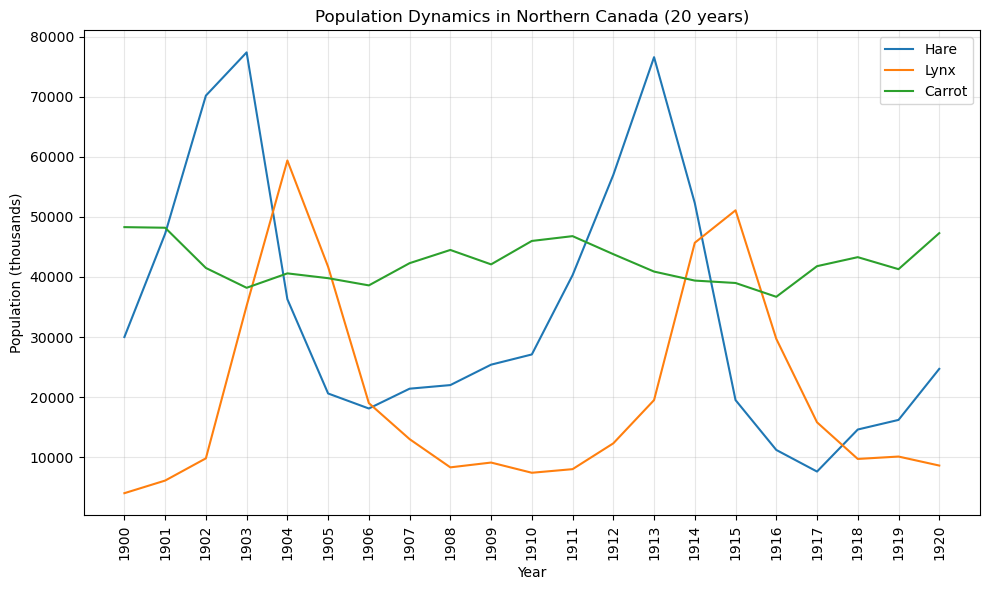

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt')
years = data[:, 0]
populations = data[:, 1:4]
species = ['Hare', 'Lynx', 'Carrot']

plt.figure(figsize=(10, 6))
plt.plot(years, populations, label=species)
plt.xlabel('Year')
plt.ylabel('Population (thousands)')
plt.title('Population Dynamics in Northern Canada (20 years)')
plt.legend()
plt.xticks(years, rotation=90)  # метки для каждого года, вертикальные
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

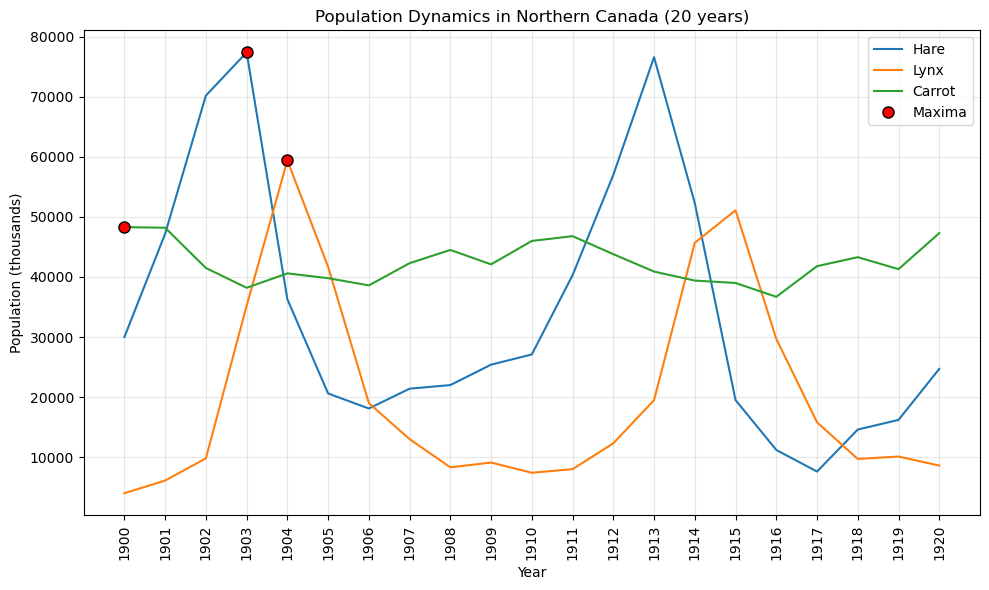

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('populations.txt')
years = data[:, 0]
populations = data[:, 1:4]
species = ['Hare', 'Lynx', 'Carrot']

plt.figure(figsize=(10, 6))
plt.plot(years, populations, label=species)
plt.xlabel('Year')
plt.ylabel('Population (thousands)')
plt.title('Population Dynamics in Northern Canada (20 years)')
plt.legend()
plt.xticks(years, rotation=90)  # метки для каждого года, вертикальные
plt.grid(True, alpha=0.3)

# Отмечаем максимумы
max_indices = np.argmax(populations, axis=0)
max_years = years[max_indices]
max_values = populations[max_indices, range(3)]
plt.plot(max_years, max_values, 'o', color='red', markersize=8, 
         markeredgecolor='black', label='Maxima')
plt.legend()  # обновляем легенду с учётом точек

plt.tight_layout()
plt.show()

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

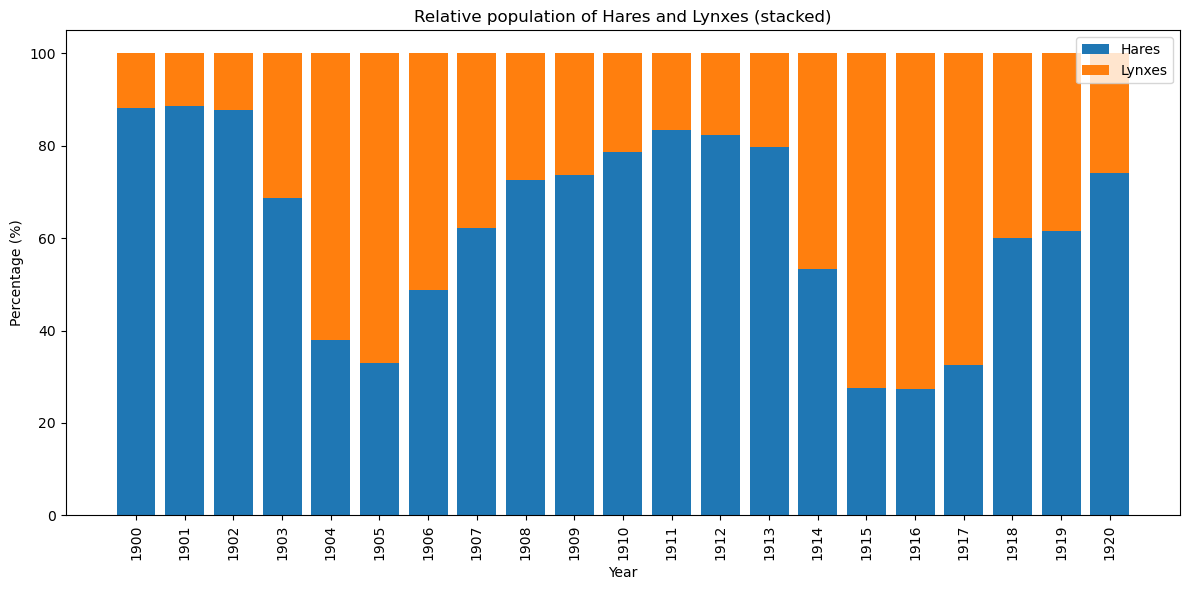

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt('populations.txt')
years = data[:, 0]
hare = data[:, 1]
lynx = data[:, 2]
# Ignore carrot (column 3) as per task

# Compute percentages
total = hare + lynx
hare_pct = (hare / total) * 100
lynx_pct = (lynx / total) * 100

# Create stacked bar plot
plt.figure(figsize=(12, 6))
plt.bar(years, hare_pct, label='Hares', width=0.8)
plt.bar(years, lynx_pct, bottom=hare_pct, label='Lynxes', width=0.8)

# Add labels and legend
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Relative population of Hares and Lynxes (stacked)')
plt.legend()
plt.xticks(years, rotation=90)  # show every year, vertical for readability
plt.tight_layout()
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

Population statistics (over 20 years):
Hare: mean = 34081.0, std = 20897.9
Lynx: mean = 20166.7, std = 16254.6
Carrot: mean = 42400.0, std = 3322.5


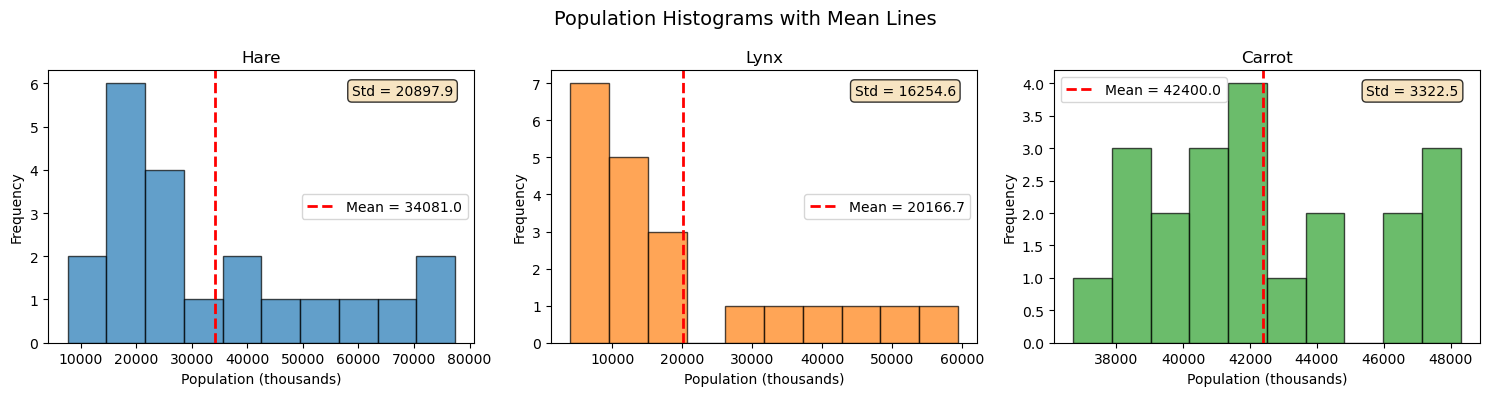

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data (ensure the file is in the working directory)
try:
    data = np.loadtxt('populations.txt')
except OSError:
    print("File 'populations.txt' not found. Please download it from the SciPy lectures repository.")
    raise

years = data[:, 0]
populations = data[:, 1:4]   # columns: hare, lynx, carrot
species = ['Hare', 'Lynx', 'Carrot']

# Calculate mean and standard deviation for each species
means = np.mean(populations, axis=0)
stds = np.std(populations, axis=0, ddof=0)   # population standard deviation (ddof=0)

# Print the statistics
print("Population statistics (over 20 years):")
for i, name in enumerate(species):
    print(f"{name}: mean = {means[i]:.1f}, std = {stds[i]:.1f}")

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Population Histograms with Mean Lines', fontsize=14)

# Plot histogram for each species
for i, ax in enumerate(axes):
    # Histogram of the species' population data
    ax.hist(populations[:, i], bins=10, edgecolor='black', alpha=0.7, color=f'C{i}')
    # Vertical line at the mean
    ax.axvline(means[i], color='red', linestyle='--', linewidth=2, label=f'Mean = {means[i]:.1f}')
    # Add standard deviation as text annotation
    ax.text(0.95, 0.95, f'Std = {stds[i]:.1f}', transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.set_title(f'{species[i]}')
    ax.set_xlabel('Population (thousands)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

Winner each year (H = Hares, L = Lynxes):
['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']


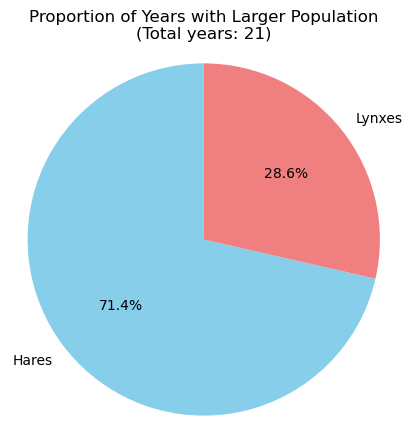

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data (make sure populations.txt is in the working directory)
try:
    data = np.loadtxt('populations.txt')
except OSError:
    print("Error: populations.txt not found. Please download it from the SciPy lectures repository.")
    raise

# Extract columns: year, hare, lynx (carrot is ignored)
years = data[:, 0]
hare = data[:, 1]
lynx = data[:, 2]

# Compare populations and create a list of winners
winners = []
for h, l in zip(hare, lynx):
    if h > l:
        winners.append('H')
    elif l > h:
        winners.append('L')
    else:
        # In case of a tie (unlikely), we arbitrarily choose 'H' and warn
        print(f"Warning: tie at year {years[len(winners)]}, assigning 'H'")
        winners.append('H')

# Print the result as a Python list
print("Winner each year (H = Hares, L = Lynxes):")
print(winners)

# Count how many times each species wins
count_h = winners.count('H')
count_l = winners.count('L')

# Create a pie chart
plt.figure(figsize=(5, 5))
plt.pie([count_h, count_l], labels=['Hares', 'Lynxes'], autopct='%1.1f%%',
        colors=['skyblue', 'lightcoral'], startangle=90)
plt.title(f'Proportion of Years with Larger Population\n(Total years: {len(years)})')
plt.axis('equal')  # ensure the pie is circular
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

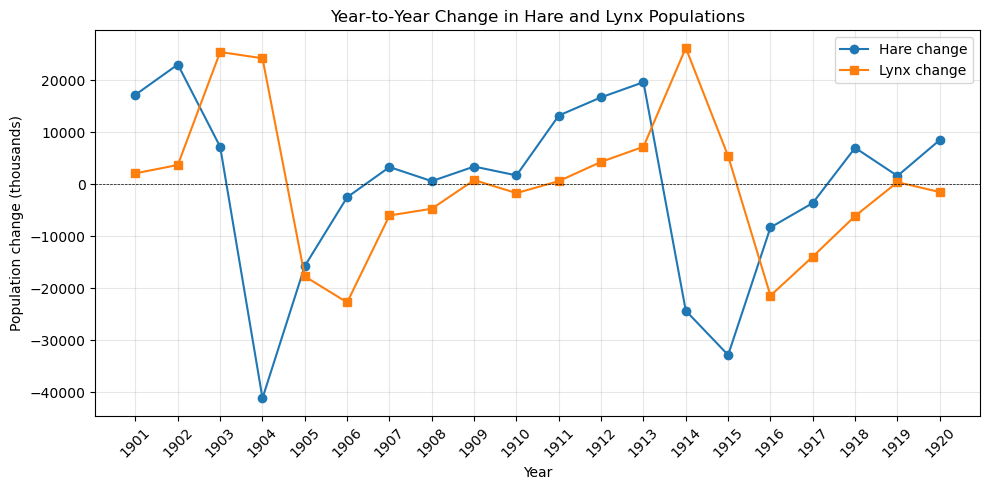

Pearson correlation coefficient between hare and lynx changes: -0.178


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
try:
    data = np.loadtxt('populations.txt')
except OSError:
    print("File 'populations.txt' not found. Please download it from the SciPy lectures repository.")
    raise

years = data[:, 0]
hare = data[:, 1]
lynx = data[:, 2]

# Compute year-to-year changes (first differences)
hare_change = np.diff(hare)   # hare[i+1] - hare[i]
lynx_change = np.diff(lynx)
change_years = years[1:]      # the years corresponding to the changes (from year i to i+1)

# Plot the changes
plt.figure(figsize=(10, 5))
plt.plot(change_years, hare_change, 'o-', label='Hare change', color='C0')
plt.plot(change_years, lynx_change, 's-', label='Lynx change', color='C1')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Population change (thousands)')
plt.title('Year‑to‑Year Change in Hare and Lynx Populations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(change_years, rotation=45)
plt.tight_layout()
plt.show()

# Compute the correlation coefficient between the two change series
corr_matrix = np.corrcoef(hare_change, lynx_change)
correlation = corr_matrix[0, 1]
print(f"Pearson correlation coefficient between hare and lynx changes: {correlation:.3f}")


- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

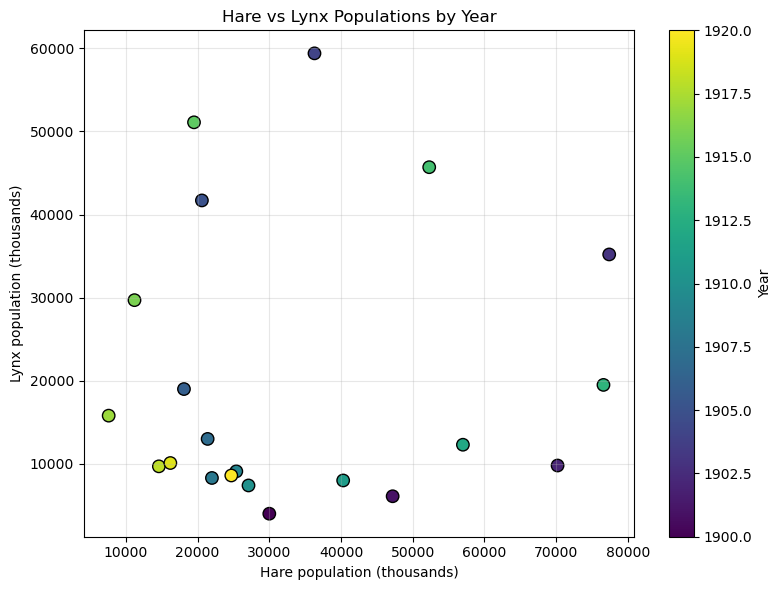

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt('populations.txt')
years = data[:, 0]
hare = data[:, 1]
lynx = data[:, 2]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(hare, lynx, c=years, cmap='viridis', edgecolors='black', s=80)
plt.colorbar(label='Year')
plt.xlabel('Hare population (thousands)')
plt.ylabel('Lynx population (thousands)')
plt.title('Hare vs Lynx Populations by Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

True hare population in 1920: 24700.0
Estimated hare population (linear trend): 19775.8
Relative error (|est - true| / true): 0.199


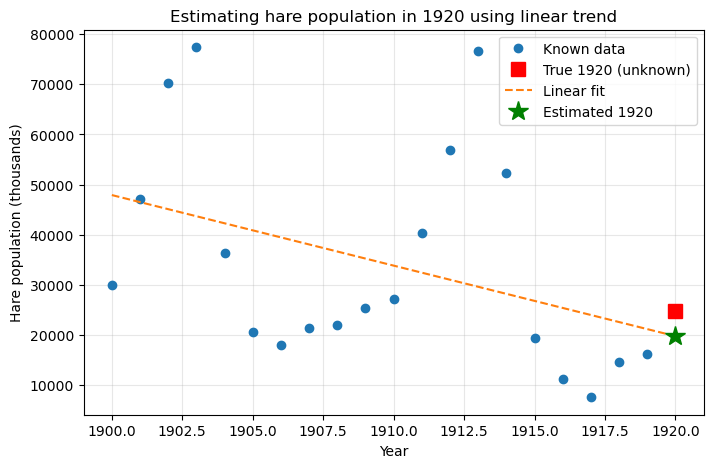

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data = np.loadtxt('populations.txt')
    years = data[:, 0]
    hare = data[:, 1]
except OSError:
    print("Error: populations.txt not found. Please download it from the SciPy lectures repository.")
    raise

# Identify the index for the year 1920
try:
    idx_1920 = list(years).index(1920)
except ValueError:
    print("Year 1920 not found in the dataset. Please check the data range.")
    raise

true_hare_1920 = hare[idx_1920]

# Create a mask that excludes 1920
mask = np.ones(len(years), dtype=bool)
mask[idx_1920] = False


coeffs = np.polyfit(years[mask], hare[mask], 1)  # returns [slope, intercept]
linear_trend = np.poly1d(coeffs)

# Estimate hare population for 1920
estimated_hare_1920 = linear_trend(1920)


error_ratio = abs(estimated_hare_1920 - true_hare_1920) / true_hare_1920


print(f"True hare population in 1920: {true_hare_1920:.1f}")
print(f"Estimated hare population (linear trend): {estimated_hare_1920:.1f}")
print(f"Relative error (|est - true| / true): {error_ratio:.3f}")


plt.figure(figsize=(8, 5))
plt.plot(years[mask], hare[mask], 'o', label='Known data')
plt.plot(years[idx_1920], hare[idx_1920], 'rs', markersize=10, label='True 1920 (unknown)')
plt.plot(years, linear_trend(years), '--', label='Linear fit')
plt.plot(1920, estimated_hare_1920, 'g*', markersize=15, label='Estimated 1920')
plt.xlabel('Year')
plt.ylabel('Hare population (thousands)')
plt.title('Estimating hare population in 1920 using linear trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
